In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Učitavanje dataseta sa Drive-a
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Masinsko/drugi/crop.csv')

print("Oblik dataseta:", df.shape)
print("\nPrvih 5 redova:")
df.head()

Oblik dataseta: (2200, 8)

Prvih 5 redova:


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


In [ ]:
# Pregled podataka
print("Tipovi kolona:")
print(df.dtypes)

print("\nStatistički pregled:")
df.describe()

Tipovi kolona:
Nitrogen         int64
Phosphorus       int64
Potassium        int64
Temperature    float64
Humidity       float64
pH_Value       float64
Rainfall       float64
Crop            object
dtype: object

Statistički pregled:


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
# Provera nedostajućih vrednosti
print("Nedostajuće vrednosti po kolonama:")
print(df.isnull().sum())

print("\nRaspodela klasa (useva):")
print(df['Crop'].value_counts())

Nedostajuće vrednosti po kolonama:
Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
dtype: int64

Raspodela klasa (useva):
Crop
Rice           100
Maize          100
ChickPea       100
KidneyBeans    100
PigeonPeas     100
MothBeans      100
MungBean       100
Blackgram      100
Lentil         100
Pomegranate    100
Banana         100
Mango          100
Grapes         100
Watermelon     100
Muskmelon      100
Apple          100
Orange         100
Papaya         100
Coconut        100
Cotton         100
Jute           100
Coffee         100
Name: count, dtype: int64


In [ ]:
# Priprema podataka
X = df.drop(columns=['Crop'])
y = df['Crop']

# Label encoding ciljne promenljive
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Feature-i:", list(X.columns))
print("Broj klasa:", len(le.classes_))
print("Klase:", le.classes_)

Feature-i: ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']
Broj klasa: 22
Klase: ['Apple' 'Banana' 'Blackgram' 'ChickPea' 'Coconut' 'Coffee' 'Cotton'
 'Grapes' 'Jute' 'KidneyBeans' 'Lentil' 'Maize' 'Mango' 'MothBeans'
 'MungBean' 'Muskmelon' 'Orange' 'Papaya' 'PigeonPeas' 'Pomegranate'
 'Rice' 'Watermelon']


In [ ]:
# Podela na trening i test skup (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Trening skup:", X_train.shape)
print("Test skup:  ", X_test.shape)

Trening skup: (1760, 7)
Test skup:   (440, 7)


In [ ]:
# Trening modela stabla odlučivanja
model = DecisionTreeClassifier(
    max_depth=15,        # ograničavamo dubinu radi generalizacije
    min_samples_leaf=5,  # minimum uzoraka po listu
    random_state=42
)

model.fit(X_train, y_train)

# Evaluacija
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Tačnost na test skupu: {acc * 100:.2f}%")

Tačnost na test skupu: 97.50%


In [ ]:
# Detaljan izveštaj klasifikacije
print("Izveštaj klasifikacije:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Izveštaj klasifikacije:

              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        20
      Banana       1.00      1.00      1.00        20
   Blackgram       1.00      0.85      0.92        20
    ChickPea       1.00      1.00      1.00        20
     Coconut       1.00      1.00      1.00        20
      Coffee       1.00      1.00      1.00        20
      Cotton       0.95      1.00      0.98        20
      Grapes       1.00      1.00      1.00        20
        Jute       0.95      0.95      0.95        20
 KidneyBeans       1.00      1.00      1.00        20
      Lentil       0.82      0.90      0.86        20
       Maize       0.95      1.00      0.98        20
       Mango       1.00      1.00      1.00        20
   MothBeans       0.80      0.80      0.80        20
    MungBean       1.00      1.00      1.00        20
   Muskmelon       1.00      1.00      1.00        20
      Orange       1.00      1.00      1.00        20
  

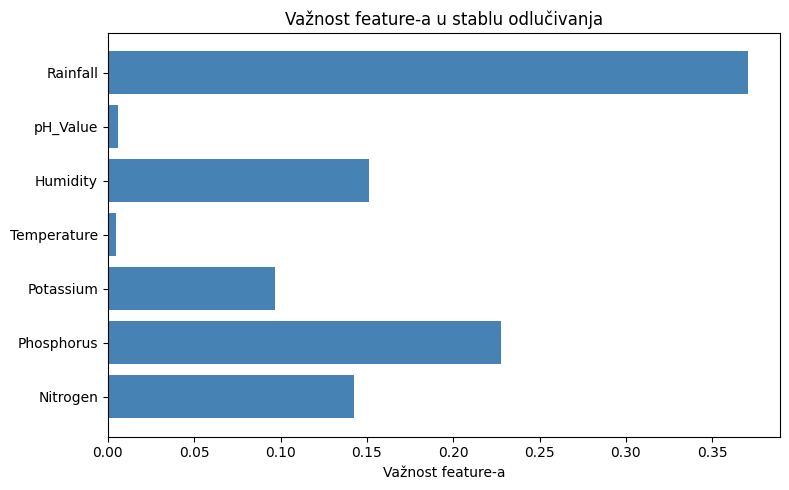

In [ ]:
# Vizualizacija važnosti feature-a
importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances, color='steelblue')
plt.xlabel("Važnost feature-a")
plt.title("Važnost feature-a u stablu odlučivanja")
plt.tight_layout()
plt.show()

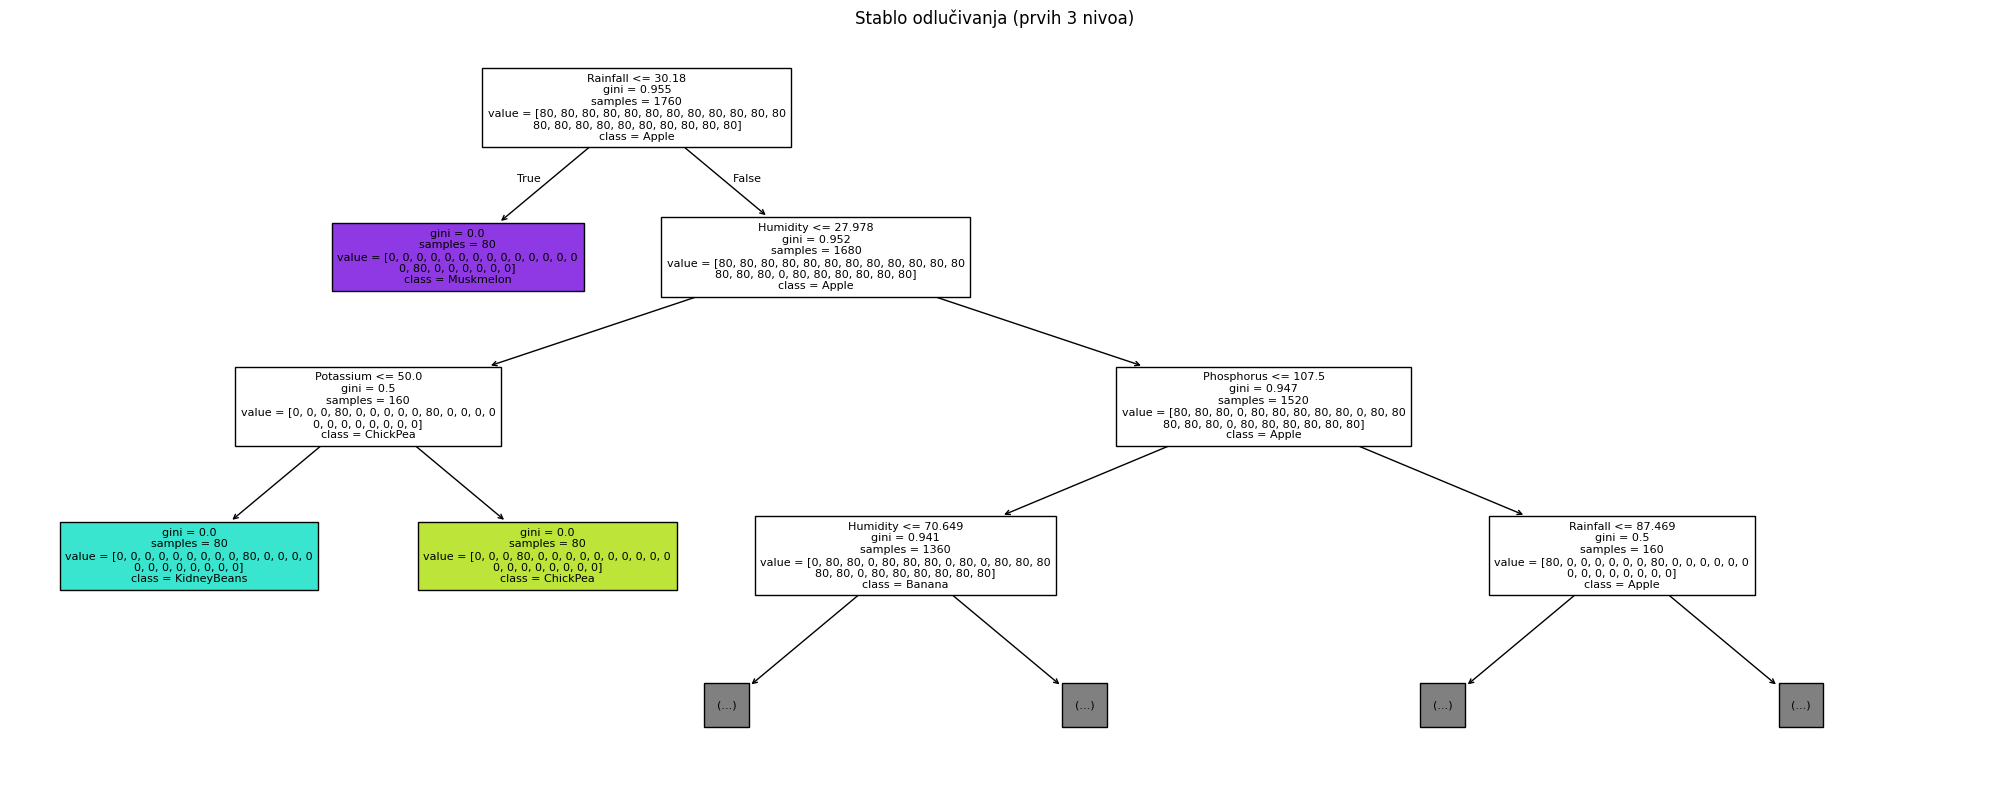

In [ ]:
# Vizualizacija stabla (prvih nekoliko nivoa)
plt.figure(figsize=(20, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    max_depth=3,   # prikazujemo samo prva 3 nivoa radi preglednosti
    fontsize=8
)
plt.title("Stablo odlučivanja (prvih 3 nivoa)")
plt.tight_layout()
plt.show()

In [ ]:
# Primer predikcije za novi uzorak
novi_uzorak = pd.DataFrame([[90, 42, 43, 20.8, 82.0, 6.5, 202.9]],
                            columns=X.columns)

predikcija = model.predict(novi_uzorak)
preporuka = le.inverse_transform(predikcija)[0]
print(f"Preporučena kultura za sejanje: {preporuka}")

Preporučena kultura za sejanje: Rice
